# Fase 4c: Lógica temporal multiclase y análisis de resolución (MobileNetV2)

**Autor:** Andoni Cabrera Fernández

**Descripción técnica:** Este cuaderno implementa el módulo de decisión temporal de la Fase 4. Carga las predicciones aisladas (`prob_ojo_cerrado` y `prob_bostezo`) extraídas previamente por los modelos independientes y aplica una serie de reglas clínicas basadas en la escala KSS:

1. Métrica **PERCLOS** para detectar el riesgo de somnolencia severa (clase 10).
2. **Duración del bostezo** (racha temporal continua) para diagnosticar estados iniciales de fatiga o baja vigilancia (clase 5).

# Fase 4c: Fusión temporal multiclase y análisis de resolución

**Autor:** Andoni Cabrera Fernández

**Descripción Técnica:** Este cuaderno implementa el módulo de decisión temporal de la Fase 4. Para ello, carga las predicciones aisladas (`prob_ojo_cerrado` y `prob_bostezo`) extraídas previamente por los modelos independientes y aplica una serie de reglas clínicas basadas en la escala KSS:

1. Métrica **PERCLOS** para detectar el riesgo de somnolencia severa (clase 10).
2. **Duración del bostezo** (racha temporal continua) para diagnosticar estados iniciales de fatiga o baja vigilancia (clase 5).

Mediante un algoritmo de búsqueda paramétrica en cuadrícula (*Grid Search*), se determina la combinación de parámetros que ofrece el mejor rendimiento. El análisis evalúa el modelo simultáneamente a 30, 15, 5 y 1 FPS, con el fin de justificar la elección de la resolución óptima para un despliegue en hardware de bajos recursos (*TinyML*).

In [ ]:
import os
import pandas as pd
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

# Montar Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Configuración del entorno y carga de predicciones por FPS
Importación de las librerías necesarias y carga de los archivos `.pkl` generados en la etapa de extracción temporal para cada una de las frecuencias de muestreo analizadas (30, 15, 5 y 1 FPS).

In [ ]:
ruta_base = '/content/drive/MyDrive/TFG_Fatiga_Colab/PKL_CNN'
print("Iniciando carga de archivos de predicciones...")

espacio_fps = [30, 15, 5, 1]
datos_dict = {}

for fps in espacio_fps:
    nombre_archivo = f'datos_TFLITE_{fps}fps.pkl'
    ruta_completa = os.path.join(ruta_base, nombre_archivo)

    if os.path.exists(ruta_completa):
        with open(ruta_completa, 'rb') as f:
            df = pickle.load(f)
            if isinstance(df, list):
                df = pd.DataFrame(df)
            datos_dict[fps] = df
        print(f" -> Cargado con éxito: {nombre_archivo} ({len(df)} registros procesados)")
    else:
        print(f" -> Advertencia: No se encontró el archivo {nombre_archivo} en {ruta_base}")

Iniciando carga de archivos de predicciones...
 -> Cargado con éxito: datos_TFLITE_30fps.pkl (3043585 registros procesados)
 -> Cargado con éxito: datos_TFLITE_15fps.pkl (1521826 registros procesados)
 -> Cargado con éxito: datos_TFLITE_5fps.pkl (507333 registros procesados)
 -> Cargado con éxito: datos_TFLITE_1fps.pkl (101538 registros procesados)


## 2. Metodología de diagnóstico temporal
Se define la lógica de decisión que evalúa la evolución temporal de las predicciones del conductor. El algoritmo calcula el PERCLOS global y la duración máxima continuada de un bostezo en cada vídeo, asignando un estado de alerta (0), baja vigilancia (5) o somnolencia severa (10) en función de los umbrales establecidos.

In [ ]:
def evaluar_video_cnn(df_video, fps, p_mod, p_sev, b_sec):
    """
    Motor lógico vectorizado. Calcula el PERCLOS global y la racha
    máxima de bostezos en todo el vídeo y aplica el árbol jerárquico.
    """
    # 1. PERCLOS GLOBAL: Porcentaje total de ojos cerrados en la secuencia
    es_cerrado = df_video['prob_ojo_cerrado'] > 0.5
    perclos_global = es_cerrado.mean()

    # 2. Bostezo: Calculamos la racha máxima continua en segundos
    es_bostezo = df_video['prob_bostezo'] > 0.5
    rachas = es_bostezo.groupby((~es_bostezo).cumsum()).sum()
    bostezo_max_sec = (rachas.max() / fps) if not rachas.empty else 0

    # 3. Árbol de Decisión Clínico (Jerarquía KSS)
    if perclos_global >= p_sev:
        return 10
    elif perclos_global >= p_mod or bostezo_max_sec >= b_sec:
        return 5
    else:
        return 0

def evaluar_dataset_completo(df, fps, p_mod, p_sev, b_sec):
    y_true, y_pred = [], []
    lista_videos = df['video'].unique()

    for vid in lista_videos:
        df_vid = df[df['video'] == vid]
        clase_real = df_vid['clase_real'].iloc[0]

        prediccion = evaluar_video_cnn(df_vid, fps, p_mod, p_sev, b_sec)

        y_true.append(clase_real)
        y_pred.append(prediccion)

    return y_true, y_pred

## 3. Optimización de hiperparámetros (Grid Search)
Para ajustar los umbrales de activación de forma objetiva, se evalúan diferentes configuraciones de hiperparámetros ($P_{mod}$, $P_{sev}$, $B_{sec}$) sobre los conjuntos de datos a distintas resoluciones. Se generan dos clasificaciones de resultados: la configuración que maximiza la métrica *F1-Score Macro* y la que maximiza la Exactitud (*Accuracy*) general.

In [ ]:
print("Iniciando búsqueda paramétrica (Grid Search)...")

espacio_fps = [30, 15, 5, 1]
espacio_p_mod = [0.02, 0.03, 0.04, 0.05]
espacio_p_sev = [0.08, 0.10, 0.12]
espacio_b_sec = [0.8, 1.2, 1.5, 2.0]

mejores_modelos_f1 = {}
mejores_modelos_acc = {}
inicio_global = time.time()

for fps in espacio_fps:
    if fps not in datos_dict:
        print(f" -> Advertencia: {fps} FPS no cargado en memoria. Saltando.")
        continue

    df_actual = datos_dict[fps]
    lista_videos = df_actual['video'].unique()

    ruta_cache_cnn = os.path.join(ruta_base, f'cache_precomputada_cnn_{fps}fps_global.pkl')

    if os.path.exists(ruta_cache_cnn):
        print(f"\n[+] Fase 1: ¡Caché encontrada! Cargando métricas globales para {fps} FPS...")
        with open(ruta_cache_cnn, 'rb') as f:
            cache_guardada = pickle.load(f)
        precomp_vids = cache_guardada['precomp_vids']
        clases_reales = cache_guardada['clases_reales']
    else:
        print(f"\n[+] Fase 1: Extrayendo métricas globales base para {fps} FPS...")
        precomp_vids = {}
        clases_reales = {}

        for vid in lista_videos:
            df_vid = df_actual[df_actual['video'] == vid].sort_values('frame_idx')
            clases_reales[vid] = df_vid['clase_real'].iloc[0]

            es_cerrado = pd.Series(df_vid['prob_ojo_cerrado'].values > 0.5)
            es_bostezo = pd.Series(df_vid['prob_bostezo'].values > 0.5)
            rachas = es_bostezo.groupby((~es_bostezo).cumsum()).sum()

            precomp_vids[vid] = {
                'perclos_global': es_cerrado.mean(),
                'bostezo_max_sec': (rachas.max() / fps) if not rachas.empty else 0
            }

        print(f"[+] Guardando caché global en Drive: cache_precomputada_cnn_{fps}fps_global.pkl")
        with open(ruta_cache_cnn, 'wb') as f:
            pickle.dump({'precomp_vids': precomp_vids, 'clases_reales': clases_reales}, f)

    mejor_f1, mejor_acc = -1, -1
    config_f1, config_acc = {}, {}

    print(f"[+] Fase 2: Ejecutando combinaciones óptimas para {fps} FPS...")
    for p_m in espacio_p_mod:
        for p_s in espacio_p_sev:
            for b_s in espacio_b_sec:

                y_true, y_pred = [], []
                for vid in lista_videos:
                    perclos_global = precomp_vids[vid]['perclos_global']
                    bostezo_max_sec = precomp_vids[vid]['bostezo_max_sec']

                    if perclos_global >= p_s: pred = 10
                    elif perclos_global >= p_m or bostezo_max_sec >= b_s: pred = 5
                    else: pred = 0

                    y_true.append(clases_reales[vid])
                    y_pred.append(pred)

                macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
                acc = accuracy_score(y_true, y_pred)

                if macro_f1 > mejor_f1:
                    mejor_f1 = macro_f1
                    config_f1 = {'P_Mod': p_m, 'P_Sev': p_s, 'B_Sec': b_s, 'Accuracy': acc, 'Macro_F1': macro_f1}
                if acc > mejor_acc:
                    mejor_acc = acc
                    config_acc = {'P_Mod': p_m, 'P_Sev': p_s, 'B_Sec': b_s, 'Accuracy': acc, 'Macro_F1': macro_f1}

    mejores_modelos_f1[fps] = config_f1
    mejores_modelos_acc[fps] = config_acc
    print(f"[!] ÉXITO: Búsqueda completada para el entorno de {fps} FPS.")

print(f"\n>>> Grid Search Global finalizado en {time.time() - inicio_global:.2f} segundos.")

Iniciando búsqueda paramétrica (Grid Search)...

[+] Fase 1: ¡Caché encontrada! Cargando métricas globales para 30 FPS...
[+] Fase 2: Ejecutando combinaciones óptimas para 30 FPS...
[!] ÉXITO: Búsqueda completada para el entorno de 30 FPS.

[+] Fase 1: ¡Caché encontrada! Cargando métricas globales para 15 FPS...
[+] Fase 2: Ejecutando combinaciones óptimas para 15 FPS...
[!] ÉXITO: Búsqueda completada para el entorno de 15 FPS.

[+] Fase 1: ¡Caché encontrada! Cargando métricas globales para 5 FPS...
[+] Fase 2: Ejecutando combinaciones óptimas para 5 FPS...
[!] ÉXITO: Búsqueda completada para el entorno de 5 FPS.

[+] Fase 1: ¡Caché encontrada! Cargando métricas globales para 1 FPS...
[+] Fase 2: Ejecutando combinaciones óptimas para 1 FPS...
[!] ÉXITO: Búsqueda completada para el entorno de 1 FPS.

>>> Grid Search Global finalizado en 1.31 segundos.


## 4. Reporte comparativo de rendimiento (F1-Score frente a Exactitud)

In [ ]:
print("-" * 110)
print("RESULTADOS PRIORIZANDO F1-SCORE (Prioridad: Evitar Falsos Negativos)")
print("-" * 110)
for fps, top in mejores_modelos_f1.items():
    print(f"[{fps} FPS] F1: {top['Macro_F1']:.4f} | Acc: {top['Accuracy']:.4f} --> P_Mod: {top['P_Mod']} | P_Sev: {top['P_Sev']} | B_Sec: {top['B_Sec']}s")

print("\n" + "-" * 110)
print("RESULTADOS PRIORIZANDO ACCURACY (Prioridad: Evitar Falsas Alarmas)")
print("-" * 110)
for fps, top in mejores_modelos_acc.items():
    print(f"[{fps} FPS] Acc: {top['Accuracy']:.4f} | F1: {top['Macro_F1']:.4f} --> P_Mod: {top['P_Mod']} | P_Sev: {top['P_Sev']} | B_Sec: {top['B_Sec']}s")
print("-" * 110)

--------------------------------------------------------------------------------------------------------------
RESULTADOS PRIORIZANDO F1-SCORE (Prioridad: Evitar Falsos Negativos)
--------------------------------------------------------------------------------------------------------------
[30 FPS] F1: 0.2301 | Acc: 0.3833 --> P_Mod: 0.04 | P_Sev: 0.08 | B_Sec: 2.0s
[15 FPS] F1: 0.2289 | Acc: 0.3833 --> P_Mod: 0.04 | P_Sev: 0.08 | B_Sec: 2.0s
[5 FPS] F1: 0.2225 | Acc: 0.3778 --> P_Mod: 0.03 | P_Sev: 0.08 | B_Sec: 2.0s
[1 FPS] F1: 0.2025 | Acc: 0.3944 --> P_Mod: 0.04 | P_Sev: 0.08 | B_Sec: 1.2s

--------------------------------------------------------------------------------------------------------------
RESULTADOS PRIORIZANDO ACCURACY (Prioridad: Evitar Falsas Alarmas)
--------------------------------------------------------------------------------------------------------------
[30 FPS] Acc: 0.3889 | F1: 0.2222 --> P_Mod: 0.03 | P_Sev: 0.12 | B_Sec: 1.2s
[15 FPS] Acc: 0.3944 | F1: 0.22

## 5. Análisis de rendimiento por resolución temporal

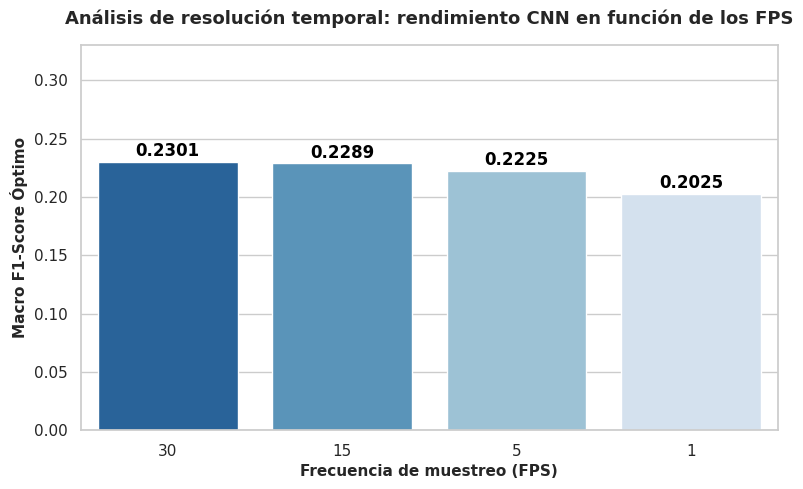

In [ ]:
# Graficaremos la máxima capacidad predictiva (F1-Score) por resolución
datos_grafico = [{'FPS': fps, 'Max_F1': config['Macro_F1']} for fps, config in mejores_modelos_f1.items()]
df_grafico = pd.DataFrame(datos_grafico)

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")
grafico = sns.barplot(x='FPS', y='Max_F1', data=df_grafico, palette='Blues_r', order=[30, 15, 5, 1])

for index, row in enumerate(df_grafico.itertuples()):
    grafico.text(index, row.Max_F1 + 0.005, f"{row.Max_F1:.4f}", color='black', ha="center", fontweight='bold')

plt.title('Análisis de resolución temporal: rendimiento CNN en función de los FPS', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Frecuencia de muestreo (FPS)', fontsize=11, fontweight='bold')
plt.ylabel('Macro F1-Score Óptimo', fontsize=11, fontweight='bold')
plt.ylim(0, max(df_grafico['Max_F1']) + 0.1)
plt.show()

## 6. Ajuste paramétrico fino a 5 FPS
Tras determinar que la frecuencia de muestreo de 5 FPS ofrece un rendimiento adecuado para entornos *TinyML*, se aísla este conjunto de datos para ejecutar una búsqueda con mayor resolución y establecer los umbrales operativos definitivos.

In [ ]:
print("Iniciando búsqueda paramétrica fina a 5 FPS...")

espacio_p_mod_fino = [0.02, 0.03, 0.04, 0.05]
espacio_p_sev_fino = [0.08, 0.10, 0.12]
espacio_b_sec_fino = [1.8, 1.9, 2.0, 2.1, 2.2]

df_5fps = datos_dict[5]
mejor_f1_fino = -1
config_fina = {}
inicio_fino = time.time()

for p_m in espacio_p_mod_fino:
    for p_s in espacio_p_sev_fino:
        for b_s in espacio_b_sec_fino:

            y_true, y_pred = evaluar_dataset_completo(df_5fps, 5, p_m, p_s, b_s)

            macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
            acc = accuracy_score(y_true, y_pred)

            if macro_f1 > mejor_f1_fino:
                mejor_f1_fino = macro_f1
                config_fina = {
                    'P_Mod': p_m, 'P_Sev': p_s, 'B_Sec': b_s,
                    'Accuracy': acc, 'Macro_F1': macro_f1
                }

print(f"Búsqueda fina finalizada en {{time.time() - inicio_fino:.2f}} segundos.\n")
print("-" * 65)
print("HIPERPARÁMETROS CLÍNICOS DEFINITIVOS CNN (5 FPS - GLOBAL)")
print("-" * 65)
print(f"F1-Score: {config_fina['Macro_F1']:.4f} | Accuracy: {config_fina['Accuracy']:.4f}")
print(f"-> P_Mod (Clase 5): {config_fina['P_Mod']}")
print(f"-> P_Sev (Clase 10):{config_fina['P_Sev']}")
print(f"-> Bostezo:         {config_fina['B_Sec']}s")
print("-" * 65)

Iniciando búsqueda paramétrica fina a 5 FPS...
Búsqueda fina finalizada en {time.time() - inicio_fino:.2f} segundos.

-----------------------------------------------------------------
HIPERPARÁMETROS CLÍNICOS DEFINITIVOS CNN (5 FPS - GLOBAL)
-----------------------------------------------------------------
F1-Score: 0.2256 | Accuracy: 0.3889
-> P_Mod (Clase 5): 0.03
-> P_Sev (Clase 10):0.08
-> Bostezo:         1.8s
-----------------------------------------------------------------


## 7. Evaluación diagnóstica final y matriz de confusión
A partir de los resultados de la búsqueda paramétrica, se aplican los umbrales óptimos calculados a 5 FPS para generar la clasificación final sobre el conjunto de validación y se visualiza la matriz de confusión resultante.

Generando diagnóstico global final a 5 FPS con parámetros Fine-Tuned...


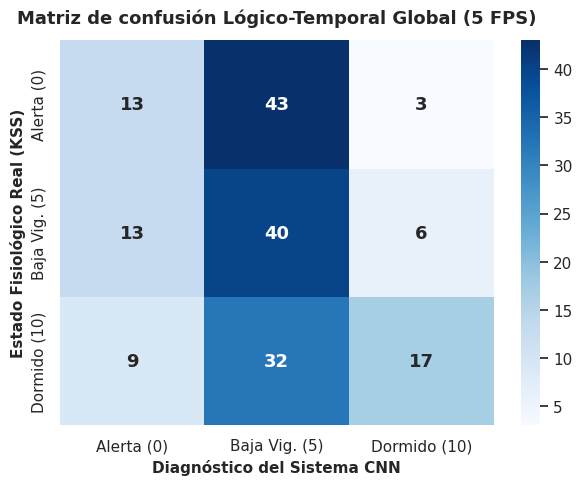


REPORTE CLÍNICO FINAL DE CLASIFICACIÓN (5 FPS)
               precision    recall  f1-score   support

   Alerta (0)       0.34      0.22      0.27        59
Baja Vig. (5)       0.35      0.68      0.46        59
 Dormido (10)       0.63      0.29      0.40        58

    micro avg       0.39      0.40      0.39       176
    macro avg       0.44      0.40      0.38       176
 weighted avg       0.44      0.40      0.38       176



In [ ]:
opt_fps = 5
opt_p_mod = config_fina['P_Mod']
opt_p_sev = config_fina['P_Sev']
opt_b = config_fina['B_Sec']

print(f"Generando diagnóstico global final a {opt_fps} FPS con parámetros Fine-Tuned...")

y_true_opt, y_pred_opt = evaluar_dataset_completo(
    df_5fps, opt_fps, opt_p_mod, opt_p_sev, opt_b
)

cm = confusion_matrix(y_true_opt, y_pred_opt, labels=[0, 5, 10])
etiquetas_clinicas = ['Alerta (0)', 'Baja Vig. (5)', 'Dormido (10)']

plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiquetas_clinicas,
            yticklabels=etiquetas_clinicas,
            annot_kws={"size": 13, "weight": "bold"})
plt.title(f'Matriz de confusión Lógico-Temporal Global ({opt_fps} FPS)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Estado Fisiológico Real (KSS)', fontsize=11, fontweight='bold')
plt.xlabel('Diagnóstico del Sistema CNN', fontsize=11, fontweight='bold')
plt.show()

print("\n" + "="*55)
print(f"REPORTE CLÍNICO FINAL DE CLASIFICACIÓN ({opt_fps} FPS)")
print("="*55)
print(classification_report(y_true_opt, y_pred_opt, labels=[0, 5, 10], target_names=etiquetas_clinicas))

## 8. Análisis Estadístico Exploratorio (EDA)
Se realiza un análisis para evaluar la distribución de la probabilidad predicha (`prob_ojo_cerrado` y `prob_bostezo`) segmentada por la clase real del conductor. Este estudio evidencia el grado de solapamiento entre los estados de fatiga y la dificultad de la red convolucional para generalizar la detección de estas regiones anatómicas de manera consistente frente a conductores desconocidos.

Iniciando Reporte Exploratorio de Datos...

--- 1. RESUMEN ESTADÍSTICO POR ESTADO (KSS) ---

>> Análisis de: PROB_OJO_CERRADO
                  count    mean     std  min     25%     50%     75%     max
Estado                                                                      
Alerta (0)     168441.0  0.0340  0.1194  0.0  0.0000  0.0004  0.0051  0.9991
Baja Vig. (5)  165522.0  0.0473  0.1490  0.0  0.0000  0.0007  0.0108  0.9995
Dormido (10)   165849.0  0.1063  0.2383  0.0  0.0001  0.0025  0.0400  0.9997

>> Análisis de: PROB_BOSTEZO
                  count    mean     std     min     25%     50%     75%  \
Estado                                                                    
Alerta (0)     168441.0  0.4444  0.3031  0.0003  0.1720  0.4116  0.7045   
Baja Vig. (5)  165522.0  0.4344  0.3095  0.0002  0.1566  0.3707  0.7069   
Dormido (10)   165849.0  0.4602  0.3106  0.0003  0.1728  0.4209  0.7428   

                  max  
Estado                 
Alerta (0)     0.9999  
Baja Vig. (

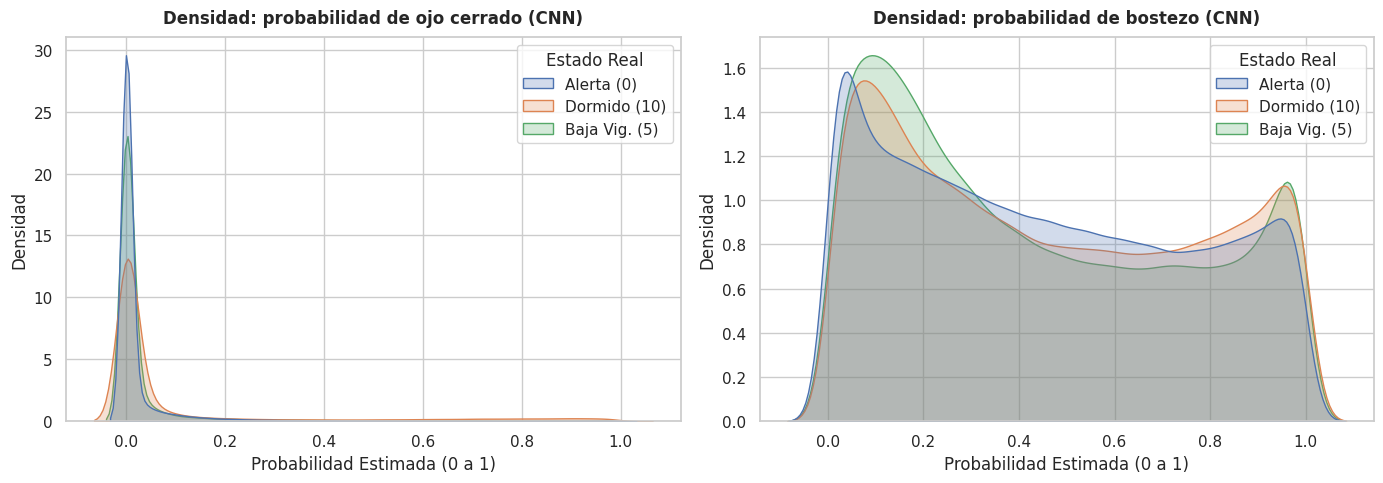


Generando serie temporal para el vídeo analizado: 01_0.mov...


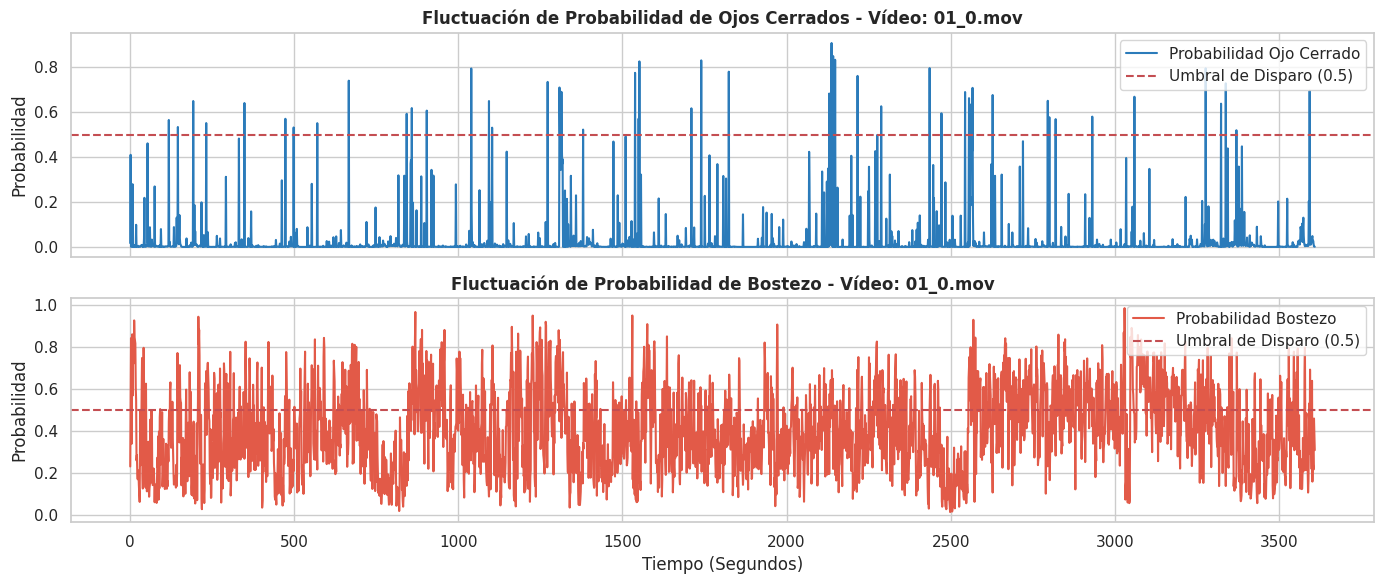


Reporte exploratorio CNN finalizado.


In [22]:
print("Iniciando Reporte Exploratorio de Datos...")

# 1. Carga de datos de la red neuronal sobre el DataFrame de 5 FPS
df_eda_cnn = df_5fps.copy()

# Mapeo de etiquetas para las gráficas
mapa_clases = {0: 'Alerta (0)', 5: 'Baja Vig. (5)', 10: 'Dormido (10)'}
df_eda_cnn['Estado'] = df_eda_cnn['clase_real'].map(mapa_clases)

# 1. Resumen Estadístico segmentado por Estado Fisiológico Real
print("\n--- 1. RESUMEN ESTADÍSTICO POR ESTADO (KSS) ---")
for biometria in ['prob_ojo_cerrado', 'prob_bostezo']:
    print(f"\n>> Análisis de: {biometria.upper()}")
    resumen_clase = df_eda_cnn.groupby('Estado')[biometria].describe().round(4)
    print(resumen_clase)

# 2. Distribución de Densidad de Probabilidades (KDE Plots)
print("\nGenerando gráficas de distribución de la red neuronal...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Gráfica Ojo Cerrado
sns.kdeplot(data=df_eda_cnn, x="prob_ojo_cerrado", hue="Estado", fill=True,
            ax=axes[0], common_norm=False, legend=True)
axes[0].set_title('Densidad: probabilidad de ojo cerrado (CNN)', fontweight='bold', pad=10)
axes[0].set_xlabel('Probabilidad Estimada (0 a 1)')
axes[0].set_ylabel('Densidad')

# Gráfica Bostezo
sns.kdeplot(data=df_eda_cnn, x="prob_bostezo", hue="Estado", fill=True,
            ax=axes[1], common_norm=False, legend=True)
axes[1].set_title('Densidad: probabilidad de bostezo (CNN)', fontweight='bold', pad=10)
axes[1].set_xlabel('Probabilidad Estimada (0 a 1)')
axes[1].set_ylabel('Densidad')

# Forzar la visibilidad y posición de las leyendas para que no desaparezcan
if axes[0].get_legend() is not None:
    sns.move_legend(axes[0], "upper right", title='Estado Real')
if axes[1].get_legend() is not None:
    sns.move_legend(axes[1], "upper right", title='Estado Real')

# Ajustar el diseño para evitar recortes
plt.tight_layout()
plt.show()

# 3. Análisis Dinámico de Fluctuación Temporal (Muestra de Video)
video_muestra = df_eda_cnn['video'].iloc[0]
df_muestra = df_eda_cnn[df_eda_cnn['video'] == video_muestra].sort_values('frame_idx')

# Convertir fotogramas a escala temporal real (a 5 FPS, 1 fotograma = 0.2s)
df_muestra['segundos'] = df_muestra['frame_idx'] / 5.0

print(f"\nGenerando serie temporal para el vídeo analizado: {video_muestra}...")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Evolución Dinámica de Ojos Cerrados (Logit CNN)
sns.lineplot(data=df_muestra, x='segundos', y='prob_ojo_cerrado', ax=axes[0], color='#2b7bba', linewidth=1.5, label='Probabilidad Ojo Cerrado')
axes[0].axhline(y=0.5, color='r', linestyle='--', label='Umbral de Disparo (0.5)')
axes[0].set_title(f'Fluctuación de Probabilidad de Ojos Cerrados - Vídeo: {video_muestra}', fontweight='bold')
axes[0].set_ylabel('Probabilidad')
axes[0].legend(loc='upper right')

# Evolución Dinámica de Bostezos (Logit CNN)
sns.lineplot(data=df_muestra, x='segundos', y='prob_bostezo', ax=axes[1], color='#e25a48', linewidth=1.5, label='Probabilidad Bostezo')
axes[1].axhline(y=0.5, color='r', linestyle='--', label='Umbral de Disparo (0.5)')
axes[1].set_title(f'Fluctuación de Probabilidad de Bostezo - Vídeo: {video_muestra}', fontweight='bold')
axes[1].set_xlabel('Tiempo (Segundos)')
axes[1].set_ylabel('Probabilidad')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\nReporte exploratorio CNN finalizado.")